Epoch
Epoch
Epoch
Epoch
Epoch
Epoch
Epoch
Epoch
Epoch
Epoch


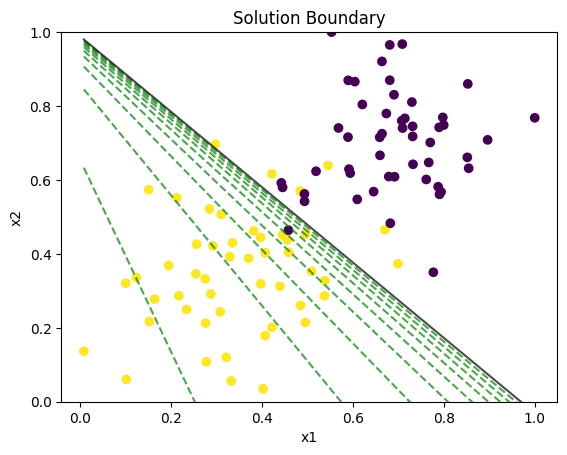

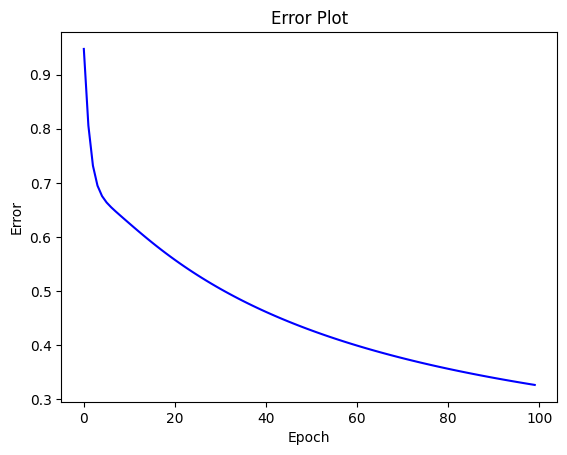

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("data.csv", header=None)
data.columns = ['x1', 'x2', 'label'] 

X = data[['x1', 'x2']].values
y = data['label'].values

learning_rate = 0.1  
epochs = 100 
log_loss_history = [] 

np.random.seed(42) 
weights = np.random.rand(2)  
bias = np.random.rand(1)

# Part 2
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def log_loss(y, y_hat):
    return -y * np.log(y_hat) - (1 - y) * np.log(1 - y_hat)

x_vals = np.array([min(X[:, 0]), max(X[:, 0])])  
for epoch in range(epochs):
    epoch_loss = 0
    
    for i in range(len(X)):
        linear_output = np.dot(X[i], weights) + bias
        y_hat = sigmoid(linear_output)
        error = y[i] - y_hat
        bias += learning_rate * error
        weights += learning_rate * error * X[i]
        epoch_loss += log_loss(y[i], y_hat)
    
    epoch_loss /= len(X)
    log_loss_history.append(epoch_loss)
    
    if epoch % 10 == 0 or epoch == epochs - 1:
        slope = -weights[0] / weights[1]
        intercept = -bias / weights[1]
        y_vals = slope * x_vals + intercept
        plt.plot(x_vals, y_vals, 'g--' if epoch < epochs - 1 else 'k-', alpha=0.7)
    
    if epoch % 10 == 0:
        print('Epoch')

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.2))
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Solution Boundary')
plt.show()

plt.plot(range(epochs), log_loss_history, 'b-')
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.title('Error Plot')
plt.show()











